# Exploring a Classification Model for Universal Cancer detecter Using Gene Expression Data

---
embed-resources: true
---

## Introduction

In this report, a model is developed to explore the potential for universal cancer detection and classification using gene expression data obtained from next-generation sequencing technologies such as RNA-Seq. One of the key challenges in this task is working with a limited dataset while aiming to build a model that can generalize well. The model that considered are Knearest Neighbors, decision tree and Logistic Regression. The Best model is Logistic Regression.

## Methods

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    confusion_matrix,
)

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# preprocessing imports
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

### Data

In [3]:
# load data
import pandas as pd
genetics_train = pd.read_parquet(
    "https://cs307.org/lab/data/genetics-train.parquet",
)
genetics_test = pd.read_parquet(
    "https://cs307.org/lab/data/genetics-test.parquet",
)

#### Data Dictionary

Each observation in the train, test, and (hidden) production data contains clinical and gene expression information from a tissue sample of a cancer patient.

#### Response

`cancer`

- `[object]` the clinically determined cancer type, one of:

    BRCA: Breast Invasive Carcinoma

    PRAD: Prostate Adenocarcinoma
 
    KIRC: Kidney Renal Clear Cell Carcinoma
 
    LUAD: Lung Adenocarcinoma
 
    COAD: Colon Adenocarcinoma

#### Features
`gene_####`

- `[float64]` gene expression (for gene number #### in the dataset) quantification as measured by an Illumina HiSeq platform

In [5]:
# summary statistics
sum(genetics_train.isna().sum())

0

There is no missing data in the gene expression features.

Text(0, 0.5, 'Count')

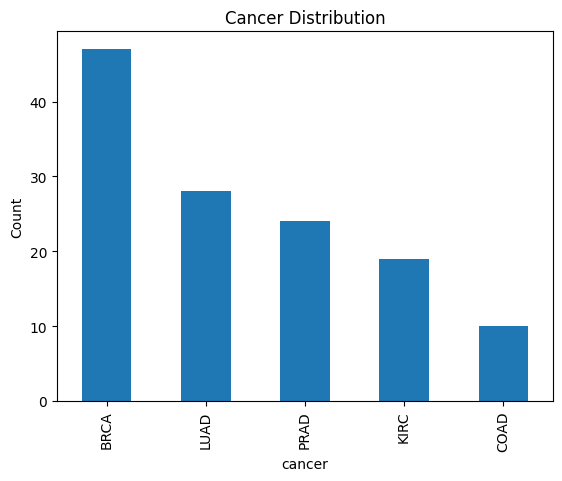

In [14]:
# exploratory visualization
genetics_train["cancer"].value_counts().plot(kind="bar")
plt.title("Cancer Distribution")
plt.ylabel("Count")

As we can see, the categorical variable `cancer` is the target variable contain different types of cancer. Although there is some difference in the number of samples for each type of cancer, the dataset is not having severe class imbalance.

### Models

In [9]:
# process data for ML

# create X and y for train
X_train = genetics_train.drop(columns=["cancer"])
y_train = genetics_train["cancer"]

# create X and y for test
X_test = genetics_test.drop(columns=["cancer"])
y_test = genetics_test["cancer"]

In [10]:
numeric_features = genetics_train.columns[1:].tolist()
categorical_features = []
features = numeric_features + categorical_features
target = "cancer"

In [11]:
# train models
dtc = DecisionTreeClassifier()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid

param_grid = {
    
    "decisiontreeclassifier__min_samples_split": [2, 5, 7, 8, 9, 10 ,20],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    dtc,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated Accuracy: {mod.best_score_}")

Best Parameters: {'decisiontreeclassifier__min_samples_split': 7}
Best Cross-Validated Accuracy: 0.8904615384615384


In [12]:
knn = KNeighborsClassifier()

param_grid = {
    
    "kneighborsclassifier__n_neighbors": [1,2, 5, 7, 8, 9, 10 ,20],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    knn,
)

# create the grid search
modknn = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
)

# fit the grid search
modknn.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {modknn.best_params_}")
print(f"Best Cross-Validated Accuracy: {modknn.best_score_}")

Best Parameters: {'kneighborsclassifier__n_neighbors': 1}
Best Cross-Validated Accuracy: 0.9923076923076923


In [18]:
import warnings
warnings.filterwarnings("ignore")
LogReg = LogisticRegression()

param_grid = {
    "logisticregression__penalty": ['l1', 'l2', None],
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__solver": ['saga'],
    "logisticregression__max_iter": [500],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    LogReg,
)

# create the grid search
modlog = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
)

# fit the grid search
modlog.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {modlog.best_params_}")
print(f"Best Cross-Validated Accuracy: {modlog.best_score_}")

Best Parameters: {'logisticregression__C': 1, 'logisticregression__max_iter': 500, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'saga'}
Best Cross-Validated Accuracy: 1.0


In this study, three supervised learning models were considered for classification: Decision Tree Classifier, K-Nearest Neighbors (KNN), and Logistic Regression. 

Each classifier was tuning using GridSearchCV with 5-fold cross-validation and accuracy as the scoring metric. For the Decision Tree Classifier, the min_samples_split parameter was explored over a range of values [2, 5, 7, 8, 9, 10, 20]. Despite tuning, the Decision Tree Classifier performed poorly relative to the other models.

For the K-Nearest Neighbors (KNN) classifier, the optimal number of neighbors was identified by searching across a range of n_neighbors values [1, 2, 5, 7, 8, 9, 10, 20]. KNN achieved a strong performance, reaching a cross-validated accuracy of 0.99 with k = 1, indicating that it was highly effective in capturing the patterns in the data.

The Logistic Regression model was also thoroughly optimized. The parameter grid included various regularization penalties (l1, l2, and None), a range of inverse regularization strengths (C values of 0.01, 0.1, 1, 10, and 100), and employed the saga solver with a max_iter setting of 500 to ensure convergence, particularly when using l1 regularization with C = 1. Logistic Regression achieved the best performance among all models with a perfect cross-validated accuracy of 1.00, indicating its suitability for this classification task.

Overall, model development involved rigorous preprocessing, systematic hyperparameter tuning, and consistent evaluation procedures. Based on comparative performance, Logistic Regression was selected as the final model due to its superior accuracy and robustness.

## Results

In [19]:
# report model metrics
accuracy = accuracy_score(y_test, modlog.predict(X_test))
accuracy

1.0

Our model achieved an accuracy of 1 on the test set.

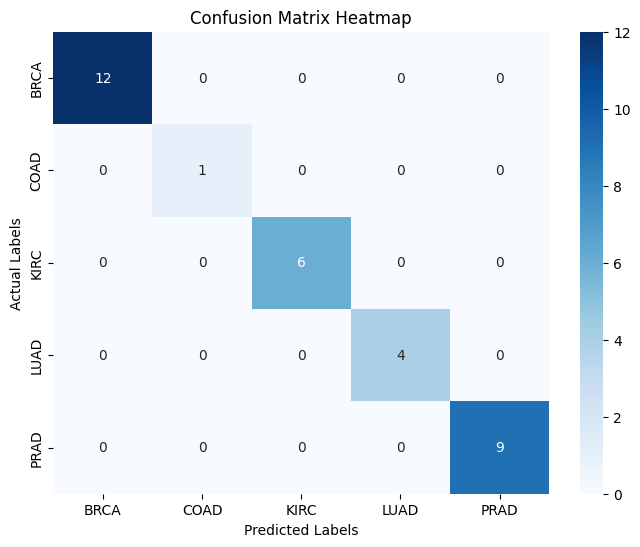

In [49]:
# summary figure
cm = confusion_matrix(y_test, modlog.predict(X_test))
# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=modlog.classes_, yticklabels=modlog.classes_)

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

From the confusion matrix, we can see that the model is able to predict all the classes correctly.

In [ ]:
# serialize model
from joblib import dump
dump(modlog, "genetics.joblib")

['genetics.joblib']

## Discussion

In [15]:
len(genetics_test)

32

Based on the results of our model evaluation, we would choose to use this model in practice, as it demonstrates exceptionally strong performance on the test dataset, achieving a perfect accuracy score of 1.0 which means that the model was able to correctly classify all instances in the test set.

However, this decision must be approached with caution, and several critical considerations need to be addressed before real-world deployment. One major concern is the limited size of the dataset, with only 128 training instances and 32 test instances. While a high test accuracy is promising, such a small sample size increases the risk of overfitting. The model may have learned patterns specific to this dataset and may not generalize well to unseen, real-world data where noise, variation, and edge cases are more likely. Also, the limitation of this model is that it might not be strong as there is new cancer type that is not in the training data.

To the purpose, our model is designed to simply work towards a proof of concept, not for actual use in practice. While we can put the model in context to consider how it might perform in a real-world setting, any misclassification or false negative does not put any lives at risk. The goal is to explore the feasibility of using gene expression data for cancer classification, so errors at this stage are part of the learning process. Still, reflecting on possible consequences helps us think critically about how the model would need to improve for future clinical applications.

overall, the model is performing well on the test data and can be used for our goal.